# Used Car Price Predictor

End-to-end regression project on a used-car listings dataset.  
We clean the data, explore it visually, then train and compare several models.

## 1. Imports

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

sns.set_theme(style="whitegrid")

## 2. Load Data

In [196]:
car_dataset = pd.read_csv("data/used_cars.csv")
print(car_dataset.shape)
car_dataset.head()

(4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 3. Data Overview

In [197]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [198]:
print("Missing values:", car_dataset.isna().sum().sum())
print("Duplicate rows:", car_dataset.duplicated().sum())

Missing values: 879
Duplicate rows: 0


## 4. Preprocessing

Clean raw text columns, derive useful numeric features, and remove price outliers.

In [199]:
df = car_dataset.copy()

df["price"] = pd.to_numeric(
    df["price"].astype(str).str.replace(r"[$,]", "", regex=True),
    errors="coerce"
)

df["mileage"] = pd.to_numeric(
    df["milage"].astype(str).str.replace(r"[^\d.]", "", regex=True),
    errors="coerce"
)

df["fuel_type"] = (
    df["fuel_type"]
    .replace({"–": np.nan, "not supported": np.nan, "?": np.nan})
    .fillna("Unknown")
)

df["accident"]    = df["accident"].fillna("None reported")
df["clean_title"] = df["clean_title"].fillna("No")

def simplify_transmission(v):
    v = str(v).lower()
    if "a/t" in v or "auto" in v or "dual shift" in v:
        return "Automatic"
    if "m/t" in v or "manual" in v:
        return "Manual"
    return "Other"

df["trans_simple"] = df["transmission"].apply(simplify_transmission)

df["has_accident"] = np.where(
    df["accident"].str.contains("none", case=False, na=True), 0, 1
)

df["clean_title_flag"] = np.where(
    df["clean_title"].str.lower() == "yes", 1, 0
)

df["age"] = 2024 - df["model_year"]

df["horsepower"] = pd.to_numeric(
    df["engine"].str.extract(r"(\d+\.?\d*)HP")[0],
    errors="coerce"
)
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())

df = df.dropna(subset=["price", "mileage", "age"])

q_low  = df["price"].quantile(0.01)
q_high = df["price"].quantile(0.99)
df = df[(df["price"] >= q_low) & (df["price"] <= q_high)].copy()

top_brands = df["brand"].value_counts().head(10).index
df_top = df[df["brand"].isin(top_brands)].copy()

print("Dataset shape:", df.shape)
print("Top-brands subset:", df_top.shape)
df[["price", "mileage", "age", "horsepower"]].describe().round(1)

Dataset shape: (3932, 18)
Top-brands subset: (2385, 18)


,price,mileage,age,horsepower
count,3932.0,3932.0,3932.0,3932.0
mean,39882.2,64400.4,8.4,328.0
std,34818.7,51289.8,6.0,108.5
min,4000.0,100.0,0.0,70.0
25%,17500.0,23434.5,4.0,270.0
50%,31000.0,53000.0,7.0,310.0
75%,49445.2,93106.8,12.0,382.0
max,269991.0,405000.0,50.0,1020.0


## 5. Exploratory Data Analysis

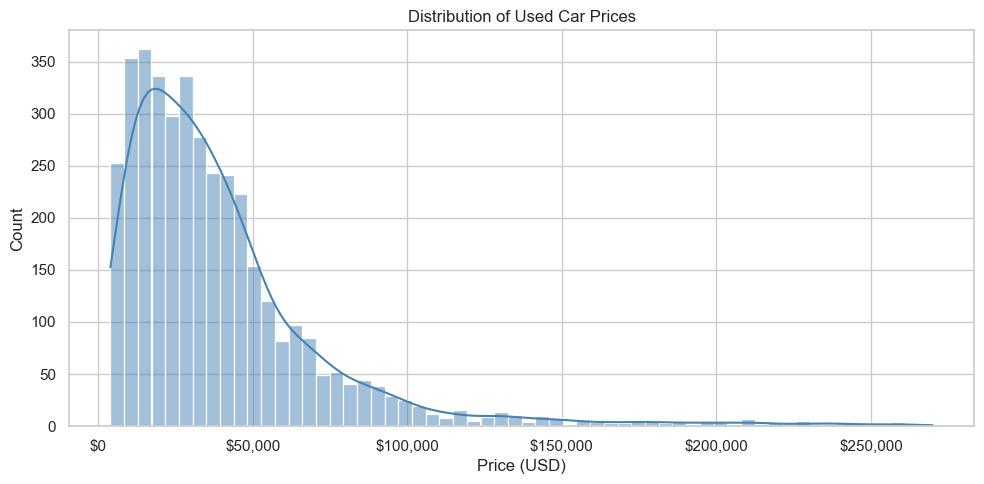

In [200]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["price"], bins=60, kde=True, color="steelblue", ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Distribution of Used Car Prices")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("01_price_distribution.png", dpi=150)
plt.show()

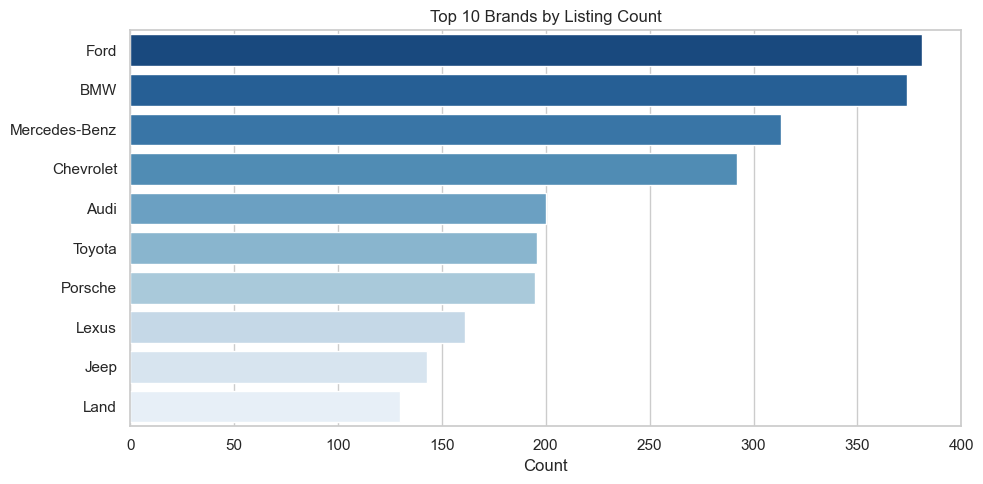

In [201]:
brand_counts = df["brand"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=brand_counts.values, y=brand_counts.index, palette="Blues_r", ax=ax)
ax.set_title("Top 10 Brands by Listing Count")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("02_top_brands.png", dpi=150)
plt.show()

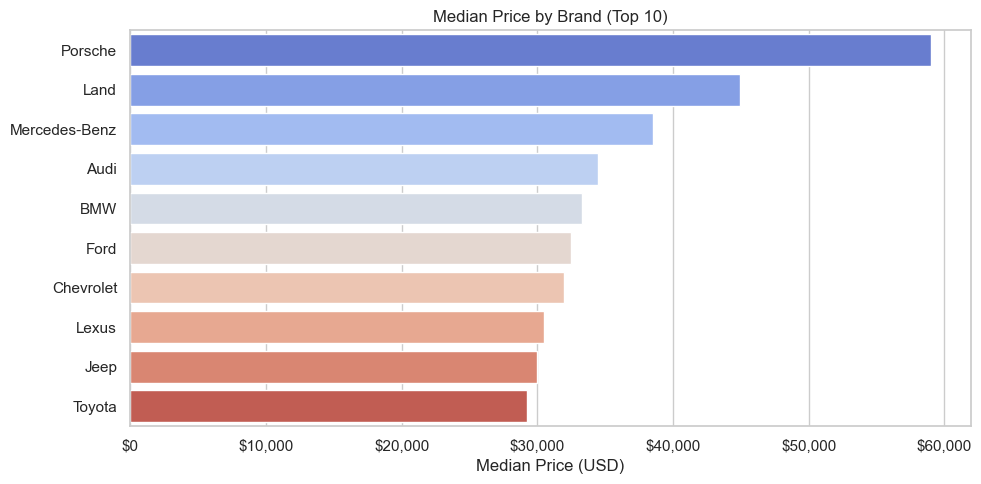

In [202]:
median_price = df_top.groupby("brand")["price"].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=median_price.values, y=median_price.index, palette="coolwarm", ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Median Price by Brand (Top 10)")
ax.set_xlabel("Median Price (USD)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("03_median_price_brand.png", dpi=150)
plt.show()

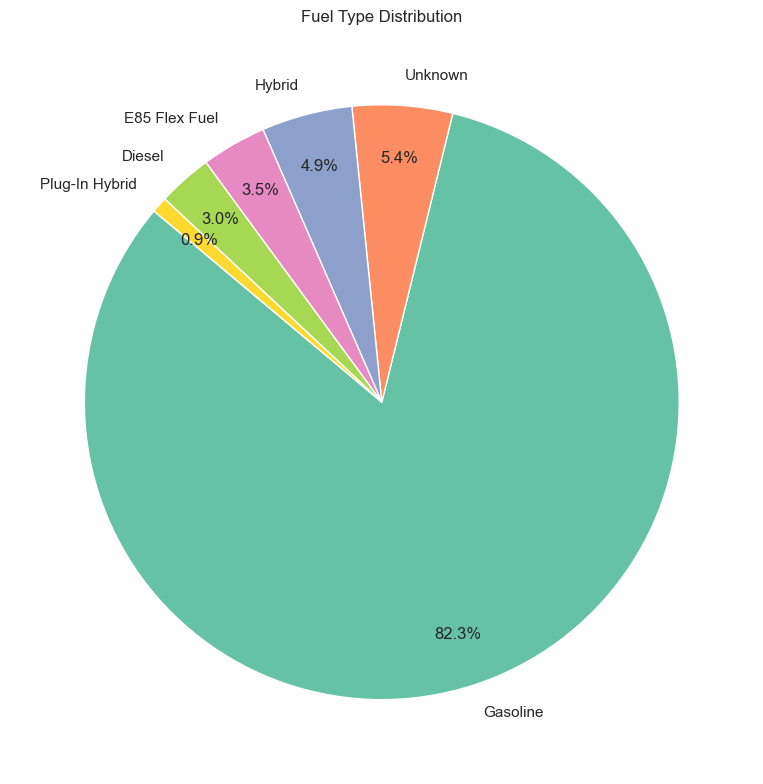

In [203]:
fuel_counts = df["fuel_type"].value_counts()
colors = sns.color_palette("Set2", len(fuel_counts))

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    fuel_counts.values,
    labels=fuel_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    pctdistance=0.82
)
ax.set_title("Fuel Type Distribution")
plt.tight_layout()
plt.savefig("04_fuel_type_pie.png", dpi=150)
plt.show()

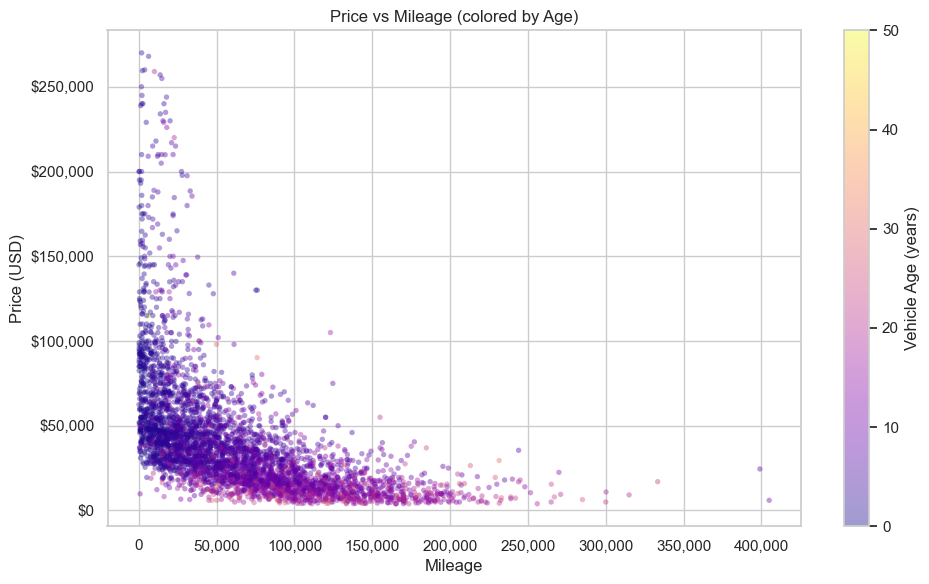

In [204]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df["mileage"], df["price"],
    c=df["age"], cmap="plasma",
    alpha=0.4, s=15, edgecolors="none"
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Vehicle Age (years)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Price vs Mileage (colored by Age)")
ax.set_xlabel("Mileage")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.savefig("05_price_vs_mileage.png", dpi=150)
plt.show()

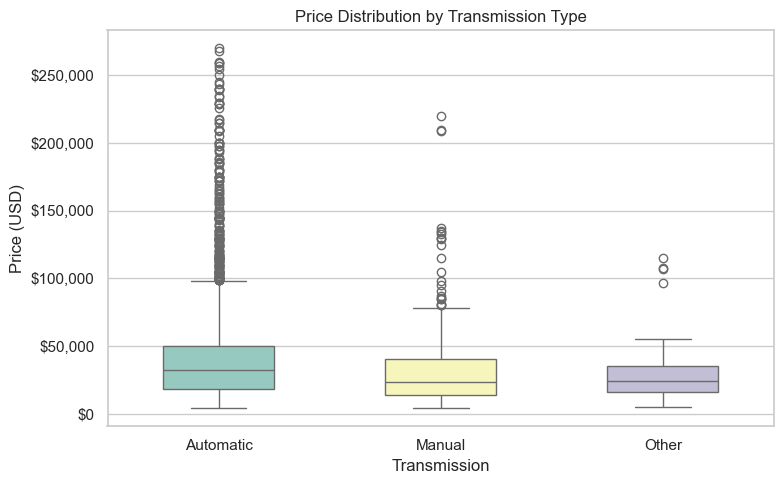

In [205]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x="trans_simple", y="price",
    palette="Set3", width=0.5, ax=ax,
    order=["Automatic", "Manual", "Other"]
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Price Distribution by Transmission Type")
ax.set_xlabel("Transmission")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.savefig("06_price_by_transmission.png", dpi=150)
plt.show()

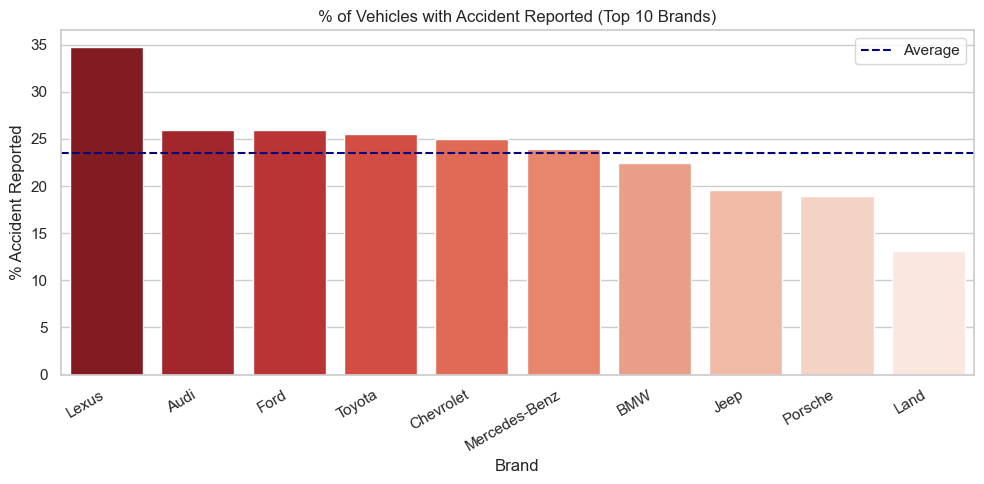

In [206]:
accident_pct = (
    df_top.groupby("brand")["has_accident"]
    .apply(lambda x: x.mean() * 100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=accident_pct.index, y=accident_pct.values, palette="Reds_r", ax=ax)
ax.axhline(y=accident_pct.mean(), color="navy", linestyle="--", label="Average")
ax.set_title("% of Vehicles with Accident Reported (Top 10 Brands)")
ax.set_ylabel("% Accident Reported")
ax.set_xlabel("Brand")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("07_accident_by_brand.png", dpi=150)
plt.show()

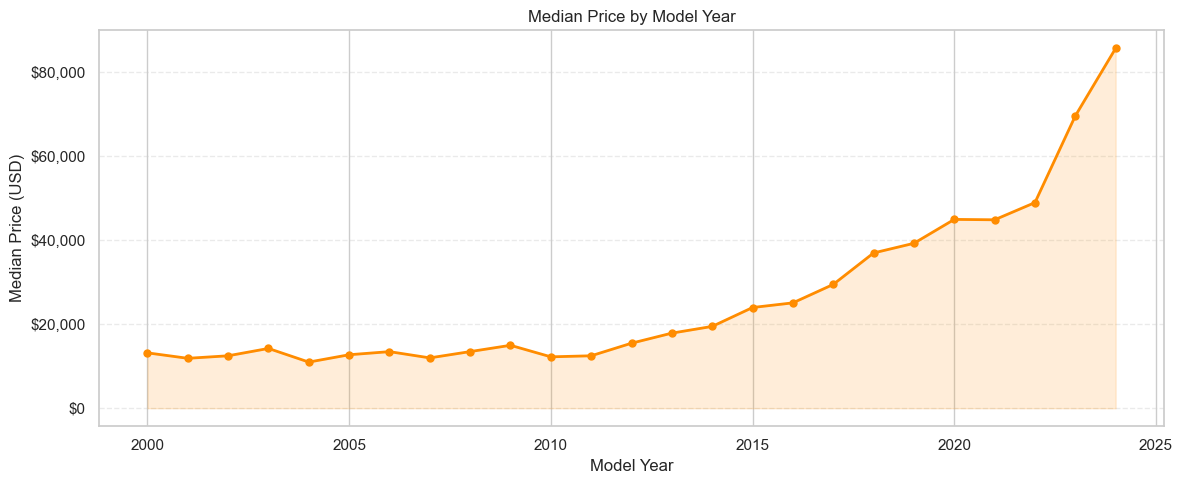

In [207]:
price_by_year = (
    df[df["model_year"] >= 2000]
    .groupby("model_year")["price"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(price_by_year["model_year"], price_by_year["price"],
        marker="o", linewidth=2, color="darkorange", markersize=5)
ax.fill_between(price_by_year["model_year"], price_by_year["price"],
                alpha=0.15, color="darkorange")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Median Price by Model Year")
ax.set_xlabel("Model Year")
ax.set_ylabel("Median Price (USD)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("08_price_by_year.png", dpi=150)
plt.show()

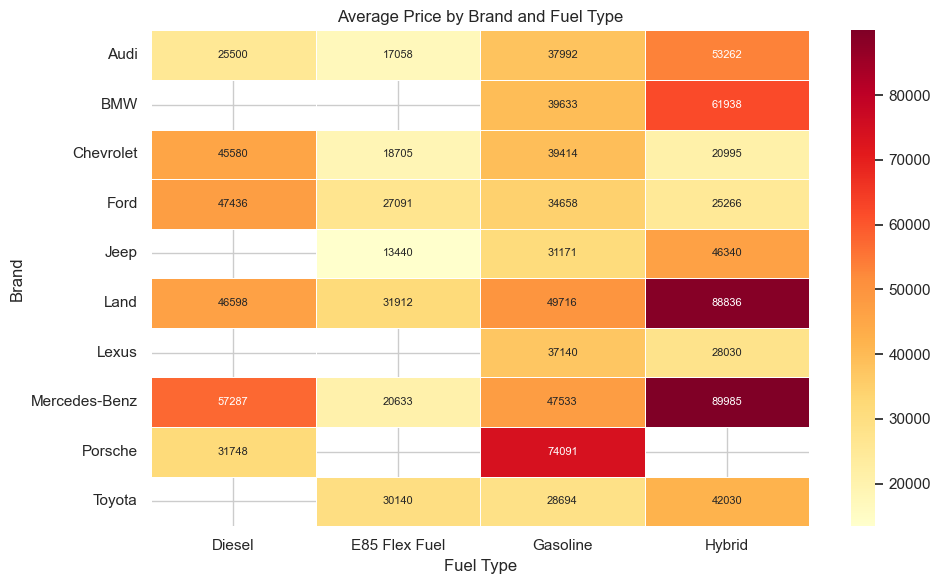

In [208]:
pivot = (
    df_top[df_top["fuel_type"].isin(["Gasoline", "Hybrid", "Diesel", "E85 Flex Fuel"])]
    .groupby(["brand", "fuel_type"])["price"]
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Average Price by Brand and Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Brand")
plt.tight_layout()
plt.savefig("09_heatmap_brand_fuel.png", dpi=150)
plt.show()

## 6. Feature Engineering

Encode categorical columns and select only numeric features for the models.

In [ ]:
df_ml = df.copy()

le = LabelEncoder()
for col in ["brand", "fuel_type", "trans_simple"]:
    df_ml[col + "_enc"] = le.fit_transform(df_ml[col].astype(str))

feature_cols = [
    "mileage",
    "age",
    "model_year",
    "horsepower",
    "has_accident",
    "clean_title_flag",
    "brand_enc",
    "fuel_type_enc",
    "trans_simple_enc",
]

X = df_ml[feature_cols].copy()
y = df_ml["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train:", X_train_sc.shape, "| Test:", X_test_sc.shape)


Train: (3145, 9) | Test: (787, 9)
Features: ['mileage', 'age', 'model_year', 'horsepower', 'has_accident', 'clean_title_flag', 'brand_enc', 'fuel_type_enc', 'trans_simple_enc']


## 7. Baseline Model Training

In [210]:
base_models = {
    "Linear Regression" : LinearRegression(),
    "Ridge Regression"  : Ridge(alpha=10),
    "Random Forest"     : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
}

results = {}
for name, model in base_models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    results[name] = {
        "MAE"   : mean_absolute_error(y_test, preds),
        "RMSE"  : np.sqrt(mean_squared_error(y_test, preds)),
        "R2"    : r2_score(y_test, preds),
        "model" : model,
        "preds" : preds,
    }

results_df = (
    pd.DataFrame({k: {"MAE": v["MAE"], "RMSE": v["RMSE"], "R2": v["R2"]}
                  for k, v in results.items()})
    .T
    .sort_values("R2", ascending=False)
    .reset_index()
    .rename(columns={"index": "Model"})
)
results_df[["MAE","RMSE"]] = results_df[["MAE","RMSE"]].round(0).astype(int)
results_df["R2"] = results_df["R2"].round(4)
results_df

,Model,MAE,RMSE,R2
0,Random Forest,9932,17946,0.7544
1,Gradient Boosting,10701,19827,0.7002
2,Linear Regression,16112,27671,0.4161
3,Ridge Regression,16101,27672,0.4161
